# 📰 Clickbait Detection with Snorkel
### Part 2 of 3: Data Augmentation with Transformation Functions

In [1]:
import os
import random
import re

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["PYTHONHASHSEED"] = "0"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 0
np.random.seed(SEED)
random.seed(SEED)

pd.set_option("display.max_colwidth", 100)

## 1. Loading data under a labeling budget

We load the gold labels for the training split, then **pretend we could only afford to hand-label 250 headlines** (125 per class). The 2,000-headline test set is the same one used in Part 1.

In [2]:
from utils import load_clickbait_dataset

df_pool, df_test = load_clickbait_dataset(load_train_labels=True)
Y_test = df_test["label"].values


def labeled_subset(n, seed=SEED):
    """Balanced random sample of n labeled headlines from the training pool."""
    return (
        df_pool.groupby("label", group_keys=False)
        .sample(n // 2, random_state=seed)
        .sample(frac=1, random_state=seed)
        .reset_index(drop=True)
    )


BUDGET = 250
df_train = labeled_subset(BUDGET)
Y_train = df_train["label"].values
print(f"Labeled training headlines: {len(df_train)}  |  test: {len(df_test):,}")
df_train.head()

Labeled training headlines: 250  |  test: 2,000


,text,label
0,Raise Your Kitchen Game With The BuzzFeed Food Newsletter,1
1,Senate Undertakes Bipartisan Ways,0
2,England win second test of the Ashes series,0
3,Women Were Pranked With Awful Makeovers... And It Was Hilarious,1
4,21 Photos That Are Way Too Real For Makeup Addicts,1


## 2. Writing transformation functions

A TF takes a data point and returns a **modified copy**, or `None` if it doesn't apply. A good TF changes the surface form while **preserving the label**. Many of ours use spaCy for part-of-speech tags and named entities, through a memoized `SpacyPreprocessor`.

In [3]:
from snorkel.preprocess.nlp import SpacyPreprocessor

spacy = SpacyPreprocessor(text_field="text", doc_field="doc", memoize=True)

### a) Domain-specific TFs

* **`change_number`**: *"17 Things Only Introverts Know"* is no less clickbait as *"23 Things..."*, and *"Bus crash kills 12"* is no less news with another count. This keeps the model from memorizing specific numbers.
* **`change_place`**: swaps a country/city (spaCy `GPE` entity) for another one, so the model learns "news mentions a place", not "news mentions *Iraq*".

In [4]:
from snorkel.augmentation import transformation_function


@transformation_function()
def change_number(x):
    numbers = re.findall(r"\b\d{1,3}\b", x.text)
    if numbers:
        old = np.random.choice(numbers)
        new = str(np.random.randint(3, 51))
        x.text = re.sub(rf"\b{old}\b", new, x.text, count=1)
        return x


PLACES = [
    "India", "Brazil", "Germany", "Japan", "Kenya", "Canada", "Australia", "France", "Mexico",
    "Egypt", "Spain", "Italy", "China", "Nigeria", "Chicago", "London", "Tokyo", "Texas", "Paris",
]


@transformation_function(pre=[spacy])
def change_place(x):
    places = [ent.text for ent in x.doc.ents if ent.label_ == "GPE"]
    if places:
        old = np.random.choice(places)
        x.text = x.text.replace(old, np.random.choice([p for p in PLACES if p != old]))
        return x

### b) WordNet synonym TFs

We replace a random noun, verb or adjective with a WordNet synonym. Unlike the reference version, we **keep the original token's capitalisation**, which matters for Title-Case headlines (*"Awful"* → *"Terrible"*, not *"terrible"*).

In [5]:
import nltk
from nltk.corpus import wordnet as wn

nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)


def get_synonym(word, pos=None):
    """First WordNet lemma for `word` that differs from it, or None."""
    synsets = wn.synsets(word, pos=pos)
    if synsets:
        for lemma in synsets[0].lemmas():
            if lemma.name().lower() != word.lower():
                return lemma.name().replace("_", " ")


def match_case(source, target):
    return target[:1].upper() + target[1:] if source[:1].isupper() else target


def replace_token(spacy_doc, idx, replacement):
    """Replace token idx, keeping the original whitespace (no 'It 's' artifacts)."""
    token = spacy_doc[idx]
    return spacy_doc[:idx].text_with_ws + replacement + token.whitespace_ + spacy_doc[idx + 1 :].text


def replace_pos_with_synonym(x, spacy_pos, wordnet_pos):
    idxs = [i for i, token in enumerate(x.doc) if token.pos_ == spacy_pos]
    if idxs:
        idx = np.random.choice(idxs)
        synonym = get_synonym(x.doc[idx].text, pos=wordnet_pos)
        if synonym:
            x.text = replace_token(x.doc, idx, match_case(x.doc[idx].text, synonym))
            return x


@transformation_function(pre=[spacy])
def replace_noun_with_synonym(x):
    return replace_pos_with_synonym(x, "NOUN", "n")


@transformation_function(pre=[spacy])
def replace_verb_with_synonym(x):
    return replace_pos_with_synonym(x, "VERB", "v")


@transformation_function(pre=[spacy])
def replace_adjective_with_synonym(x):
    return replace_pos_with_synonym(x, "ADJ", "a")

### c) Random word deletion

From *EDA: Easy Data Augmentation* (Wei & Zou, 2019). We drop one random token (never the first) from headlines with at least 6 tokens, so the model can't rely on any single word.

In [6]:
@transformation_function(pre=[spacy])
def delete_random_word(x):
    if len(x.doc) >= 6:
        idx = np.random.randint(1, len(x.doc))
        x.text = "".join(t.text_with_ws for i, t in enumerate(x.doc) if i != idx).strip()
        return x

In [7]:
tfs = [
    change_number,
    change_place,
    replace_noun_with_synonym,
    replace_verb_with_synonym,
    replace_adjective_with_synonym,
    delete_random_word,
]

Let's preview one example per TF:

In [8]:
from utils import preview_tfs

preview_tfs(df_train, tfs)

,TF Name,Original Text,Transformed Text
0,change_number,Scarponi Wins Stage 6 of Giro; Armstrong Puts Finish in Perspective,Scarponi Wins Stage 47 of Giro; Armstrong Puts Finish in Perspective
1,change_place,Scarponi Wins Stage 6 of Giro; Armstrong Puts Finish in Perspective,Scarponi Wins Stage 6 of Giro; Armstrong Puts Finish in London
2,replace_noun_with_synonym,Scarponi Wins Stage 6 of Giro; Armstrong Puts Finish in Perspective,Scarponi Wins Stage 6 of Giro; Armstrong Puts Finish in Position
3,replace_verb_with_synonym,Scarponi Wins Stage 6 of Giro; Armstrong Puts Finish in Perspective,Scarponi Wins Stage 6 of Giro; Armstrong Put Finish in Perspective
4,replace_adjective_with_synonym,"33 ""Mean Girls"" Quotes Guaranteed To Make You Laugh Every Time","33 ""Average Girls"" Quotes Guaranteed To Make You Laugh Every Time"
5,delete_random_word,Scarponi Wins Stage 6 of Giro; Armstrong Puts Finish in Perspective,Scarponi Wins Stage 6 Giro; Armstrong Puts Finish in Perspective


Some outputs are a bit ungrammatical (e.g. verb synonyms that lose their inflection, or odd first-sense WordNet picks like *know → cognize* or *robot → automaton*). That's expected: [TFs don't need to be perfect](https://arxiv.org/abs/1901.11196) to help, as long as they **rarely flip the label**.

## 3. Applying TFs with a policy

A **policy** decides which TFs to chain together for each new example.

* `RandomPolicy`: picks `sequence_length` TFs uniformly at random.
* `MeanFieldPolicy`: picks TFs according to probabilities `p` that we choose. We favour `change_number` (many headlines contain numbers and the change is clearly label-safe) and give `change_place` less weight because fewer headlines mention a place.

Both generate `n_per_original=2` new headlines per original and keep the originals.

In [9]:
from snorkel.augmentation import RandomPolicy, MeanFieldPolicy, PandasTFApplier

random_policy = RandomPolicy(len(tfs), sequence_length=2, n_per_original=2, keep_original=True)

mean_field_policy = MeanFieldPolicy(
    len(tfs),
    sequence_length=2,
    n_per_original=2,
    keep_original=True,
    p=[0.25, 0.10, 0.20, 0.15, 0.15, 0.15],
)

In [10]:
df_train_aug_random = PandasTFApplier(tfs, random_policy).apply(df_train, progress_bar=False)
df_train_aug_mf = PandasTFApplier(tfs, mean_field_policy).apply(df_train, progress_bar=False)

print(f"Original training set size:            {len(df_train)}")
print(f"Augmented (RandomPolicy) size:         {len(df_train_aug_random)}")
print(f"Augmented (MeanFieldPolicy) size:      {len(df_train_aug_mf)}")

Original training set size:            250
Augmented (RandomPolicy) size:         602
Augmented (MeanFieldPolicy) size:      588


The augmented sets are a bit less than 3× the original, because a TF returns `None` when it doesn't apply (e.g. `change_place` on a headline with no place) and Snorkel skips those.

Here are some of the newly generated headlines (rows not present in the original set):

In [11]:
new_rows = df_train_aug_mf[~df_train_aug_mf.text.isin(df_train.text)]
new_rows[["text", "label"]].sample(10, random_state=SEED)

,text,label
128,Sorry But Lorelai Is Kind Of The Worst,1
60,"31 Things You Probably Didn't Cognize About ""The Good Wife""",1
10,19 Wildly Adorable Products Definitely Need In Your Life,1
166,44 Delicious Thanksgiving Dessert That Go Easy On The Sugar,1
148,Florida Pharmacy Admits Error That Might Have Kill Polo Ponies,0
188,Take This Picture Trial To Determine Your Personality Trait,1
129,We Can't Stop Looking At This Dashing Silver Who Appeared At An NDP Rally,1
43,Why You Need To Stop What You're Doing And Date A Automaton,1
55,"Actor John Fiedler, voice of Piglet and ""Bob Newhart"" regular, dead at 45",0
210,America's Cup: Team New Zealand over Alinghi in second race,0


## 4. Training a model

We featurize headlines by hashing tokens into 30,000 buckets and padding to 30 tokens (`utils.featurize_df_tokens`), then train a **1D-CNN**: an embedding layer, 64 convolution filters over 3-word windows, global max pooling and a small dense head (`utils.get_keras_cnn`). The convolutions act like learned n-gram detectors ("you won't believe", "things only"), which fits short headlines well.

In [12]:
import tensorflow as tf
from utils import featurize_df_tokens, get_keras_cnn, get_keras_lstm

X_test = featurize_df_tokens(df_test)


def train_and_test(df, build_model=get_keras_cnn, epochs=10, seed=0, num_buckets=30000):
    tf.keras.utils.set_random_seed(seed)
    model = build_model(num_buckets)
    model.fit(featurize_df_tokens(df), df["label"].values, epochs=epochs, batch_size=32, verbose=0)
    preds_test = model.predict(X_test, verbose=0)[:, 0] > 0.5
    return (preds_test == Y_test).mean()

In [13]:
lstm_acc = train_and_test(df_train, build_model=get_keras_lstm, epochs=10)
cnn_acc = train_and_test(df_train, build_model=get_keras_cnn, epochs=10)
print(f"Reference LSTM test accuracy: {lstm_acc * 100:.1f}%")
print(f"1D-CNN test accuracy:         {cnn_acc * 100:.1f}%")

Reference LSTM test accuracy: 50.0%
1D-CNN test accuracy:         87.5%


## 5. Does augmentation help? A careful comparison

The reference tutorial trains both models for the same number of epochs. But an augmented dataset that's ~2.3× larger then also gets **~2.3× more gradient updates**. Any gain could just come from training longer, not from the new examples.

So we run two comparisons, each over **5 random seeds**:

1. **Naive:** 10 epochs for both, as in the reference lab.
2. **Compute-matched:** the original-data model trains for proportionally more epochs, so both models see the **same number of gradient updates**.

In [14]:
SEEDS = [0, 1, 2, 3, 4]
BASE_EPOCHS = 10


def matched_epochs(df_original, df_augmented, base_epochs=BASE_EPOCHS):
    return int(round(base_epochs * len(df_augmented) / len(df_original)))


rows = [
    dict(setting="original, 10 epochs (naive)", seed=seed,
         acc=train_and_test(df_train, epochs=BASE_EPOCHS, seed=seed))
    for seed in SEEDS
]
for name, df_aug in [("RandomPolicy", df_train_aug_random), ("MeanFieldPolicy", df_train_aug_mf)]:
    ep_matched = matched_epochs(df_train, df_aug)
    for seed in SEEDS:
        rows.append(dict(setting=f"original, {ep_matched} epochs (compute-matched to {name})", seed=seed,
                         acc=train_and_test(df_train, epochs=ep_matched, seed=seed)))
        rows.append(dict(setting=f"augmented ({name}), 10 epochs", seed=seed,
                         acc=train_and_test(df_aug, epochs=BASE_EPOCHS, seed=seed)))

comparison = (
    pd.DataFrame(rows)
    .groupby("setting", sort=False)["acc"]
    .agg(["mean", "std"])
    .mul(100)
    .round(2)
    .rename(columns={"mean": "test_acc_mean_%", "std": "test_acc_std_%"})
)
comparison

,test_acc_mean_%,test_acc_std_%
setting,,
"original, 10 epochs (naive)",86.97,1.95
"original, 24 epochs (compute-matched to RandomPolicy)",88.44,1.47
"augmented (RandomPolicy), 10 epochs",87.77,1.17
"original, 24 epochs (compute-matched to MeanFieldPolicy)",88.44,1.47
"augmented (MeanFieldPolicy), 10 epochs",88.25,0.74


## 6. Learning curve: when is augmentation worth it?

In [15]:
budgets = [50, 100, 250, 500, 1000]
curve = []
for n in budgets:
    df_small = labeled_subset(n)
    df_small_aug = PandasTFApplier(tfs, mean_field_policy).apply(df_small, progress_bar=False)
    ep_matched = matched_epochs(df_small, df_small_aug)
    for seed in SEEDS:
        curve.append(dict(budget=n, data="original (compute-matched)",
                          acc=train_and_test(df_small, epochs=ep_matched, seed=seed)))
        curve.append(dict(budget=n, data="augmented",
                          acc=train_and_test(df_small_aug, epochs=BASE_EPOCHS, seed=seed)))

curve = pd.DataFrame(curve)
curve_summary = curve.groupby(["budget", "data"])["acc"].agg(["mean", "std"]).mul(100).round(2).unstack()
curve_summary

mean                                  std  \
data   augmented original (compute-matched) augmented   
budget                                                  
50         66.49                      67.13      4.62   
100        80.41                      79.56      3.85   
250        88.41                      88.44      1.03   
500        91.15                      91.28      0.28   
1000       93.09                      93.13      0.27   

                                   
data   original (compute-matched)  
budget                             
50                           4.48  
100                          3.97  
250                          1.47  
500                          0.72  
1000                         0.65

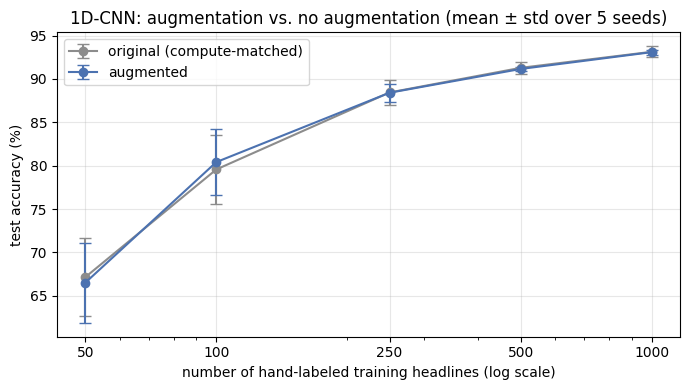

In [16]:
fig, ax = plt.subplots(figsize=(7, 4))
for data, color in [("original (compute-matched)", "#8c8c8c"), ("augmented", "#4C72B0")]:
    stats = curve[curve.data == data].groupby("budget")["acc"].agg(["mean", "std"]) * 100
    ax.errorbar(stats.index, stats["mean"], yerr=stats["std"], marker="o", capsize=4, label=data, color=color)
ax.set_xscale("log")
ax.set_xticks(budgets)
ax.set_xticklabels(budgets)
ax.set_xlabel("number of hand-labeled training headlines (log scale)")
ax.set_ylabel("test accuracy (%)")
ax.set_title("1D-CNN: augmentation vs. no augmentation (mean ± std over 5 seeds)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()